In [ ]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    
from src.states.state_simulator import StateSimulator

from src.simulation.environment import (
    DeFiEnvironment
)

from src.simulation.monte_carlo import (
    MonteCarloEngine
)

from src.portfolio.portfolio_engine import (
    PortfolioEngine
)

from src.portfolio.allocation_policies import (
    RegimeAdaptivePolicy
)

from src.risk.risk_engine import (
    RiskEngine
)


# Strategies
from src.strategies.lending import (
    PassiveLending
)

from src.strategies.carry import (
    LeveragedCarry
)

from src.strategies.amm import (
    AMMLiquidityProvision
)

from src.strategies.basis import (
    BasisArbitrage
)

from src.strategies.vol_selling import (
    VolatilitySelling
)

from src.strategies.reflexive import (
    ReflexiveYield
)

In [3]:
strategies = {

    "passive_lending":
        PassiveLending(),

    "leveraged_carry":
        LeveragedCarry(),

    "amm_lp":
        AMMLiquidityProvision(),

    "basis_arbitrage":
        BasisArbitrage(),

    "volatility_selling":
        VolatilitySelling(),

    "reflexive_yield":
        ReflexiveYield(),
}

In [4]:
state_simulator = StateSimulator()

allocation_policy = RegimeAdaptivePolicy()

portfolio_engine = PortfolioEngine()

risk_engine = RiskEngine()


environment = DeFiEnvironment(

    state_simulator=state_simulator,

    strategies=strategies,

    allocation_policy=allocation_policy,

    portfolio_engine=portfolio_engine,

    risk_engine=risk_engine,
)

In [5]:
initial_state = state_simulator.generate_state(
    regime="carry",
    timestamp=0
)

In [6]:
mc_engine = MonteCarloEngine(environment)

path = mc_engine.run_single_path(

    initial_state=initial_state,

    n_steps=50,

    initial_capital=10_000
)

In [7]:
portfolio_history = [
    step.portfolio.capital
    for step in path
]

regimes = [
    step.state.regime
    for step in path
]

In [8]:
from src.risk.metrics import (
    compute_cagr,
    compute_log_growth,
)

from src.risk.drawdown import (
    compute_max_drawdown,
)

from src.risk.volatility import (
    compute_volatility,
)


print("CAGR:")
print(compute_cagr(portfolio_history))

print()

print("Log Growth:")
print(compute_log_growth(portfolio_history))

print()

print("Volatility:")
print(compute_volatility(portfolio_history))

print()

print("Max Drawdown:")
print(compute_max_drawdown(portfolio_history))

CAGR:
0.02049874636383775

Log Growth:
0.02070558654503013

Volatility:
0.04919590111592143

Max Drawdown:
-0.2105412805843826


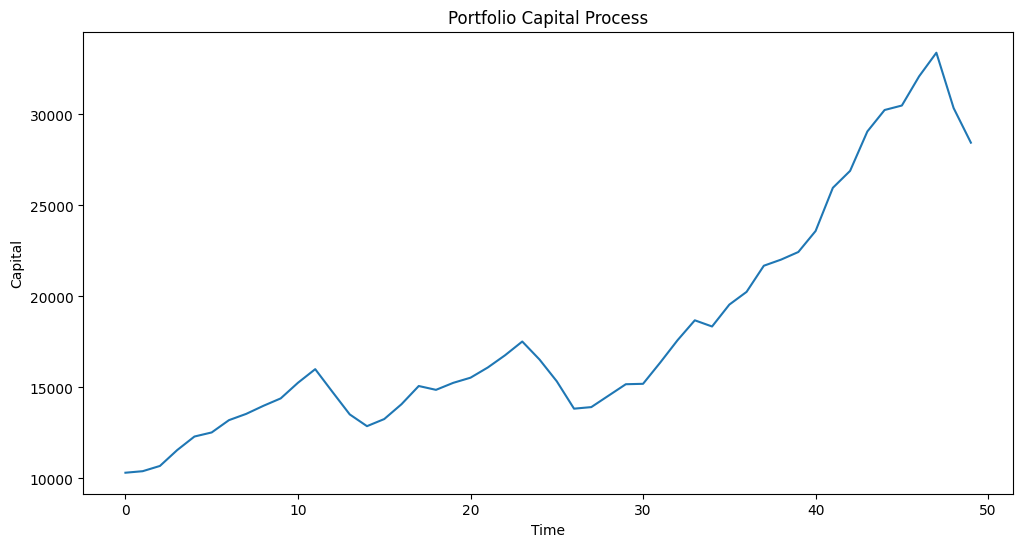

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(portfolio_history)

plt.title("Portfolio Capital Process")

plt.xlabel("Time")

plt.ylabel("Capital")

plt.show()

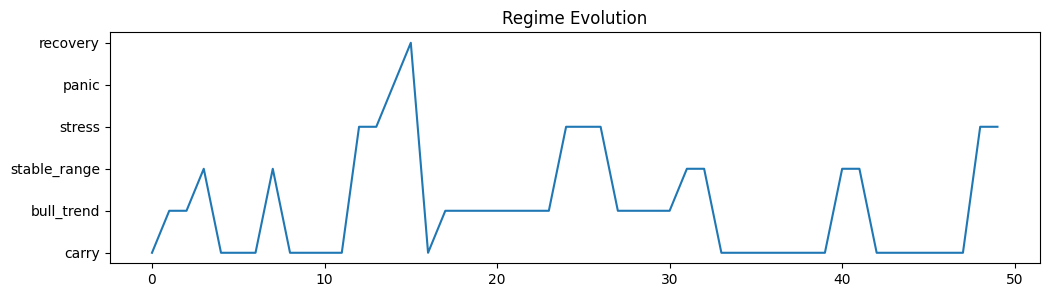

In [10]:
plt.figure(figsize=(12, 3))

plt.plot(regimes)

plt.title("Regime Evolution")

plt.show()